In [1]:
import psycopg2
import pandas as pd
import networkx as nx
import base58
import matplotlib.pyplot as plt
import re
from math import comb
import matplotlib.dates as mdates
import networkx as nx
from collections import defaultdict
from networkx.algorithms.approximation.clique import large_clique_size
from itertools import combinations
import numpy as np
from networkx.algorithms.coloring import greedy_color
import random
from collections import Counter
import requests
import time
from datetime import datetime, timedelta, timezone

In [2]:
# Connect to PostgreSQL and fetch data
conn = psycopg2.connect(
    dbname="sui_indexer",
    user="postgres",
    password="56904628",
    host="172.26.112.1",
    port=5432
)
conn.autocommit = True
cur = conn.cursor()

Write set

In [3]:
cur.execute("""
SELECT
    t.checkpoint_sequence AS checkpoint,
    oc.transaction_digest AS tx,
    oc.address AS object_address,
    c.timestamp AS timestamp
FROM transactions t
JOIN object_changes oc
  ON oc.transaction_digest = t.transaction_digest
JOIN checkpoints c
  ON c.sequence_number = t.checkpoint_sequence
WHERE oc.change_type IS NOT NULL;
""")
write_rows = cur.fetchall()

In [ ]:
IGNORED_OBJECTS = {
    f"{5:064x}": "0x5",
    f"{6:064x}": "0x6",
    f"{7:064x}": "0x7",
    f"{8:064x}": "0x8",
    f"{403:064x}": "0x403",
    f"{0xacc:064x}": "0xacc"
}

# count total writes to each ignored object
ignored_object_write_counts = Counter()

for checkpoint, tx, object_address, timestamp in write_rows:
    obj_hex = object_address.hex()

    if obj_hex in IGNORED_OBJECTS:
        ignored_object_write_counts[IGNORED_OBJECTS[obj_hex]] += 1

print(ignored_object_write_counts)

Counter({'0x6': 197541, '0x8': 21626, '0x5': 4027})


In [5]:
low_objects = Counter()

for checkpoint, tx, object_address, timestamp in write_rows:
    obj_hex = object_address.hex()

    # convert to integer
    obj_int = int(obj_hex, 16)

    # look at small addresses
    if obj_int < 0x1000:
        low_objects[hex(obj_int)] += 1

print(low_objects.most_common(20))

[('0x6', 197541), ('0x8', 21626), ('0x5', 4027), ('0x9', 59), ('0x403', 13), ('0x1', 1), ('0x2', 1), ('0x3', 1)]


Create WRITE conflict graphs with application-only subgraph

In [ ]:
# objects to ignore
IGNORED_OBJECTS = {
    f"{5:064x}",
    f"{6:064x}",
    f"{7:064x}",
    f"{8:064x}",
    f"{403:064x}",
    f"{0xacc:064x}"
}

# graphs[checkpoint] = nx.Graph()
graphs = defaultdict(nx.Graph)

# per checkpoint: object -> list of txs that wrote it
writers_by_cp_obj = defaultdict(lambda: defaultdict(list))

# all txs per checkpoint (so isolated nodes exist)
txs_by_cp = defaultdict(set)

# checkpoint -> timestamp
timestamps_by_cp = {}

for checkpoint, tx, object_address, timestamp in write_rows:
    tx_hex = tx.hex()
    obj_hex = object_address.hex()

    txs_by_cp[checkpoint].add(tx_hex)
    writers_by_cp_obj[checkpoint][obj_hex].append(tx_hex)

    # store timestamp
    if checkpoint not in timestamps_by_cp:
        timestamps_by_cp[checkpoint] = timestamp

# Build graphs
for cp, txs in txs_by_cp.items():
    G = graphs[cp]

    # 1) add all txs as nodes (isolated txs preserved)
    G.add_nodes_from(txs)

    # 2) add edges for shared-write objects
    for obj, writers in writers_by_cp_obj[cp].items():

        # skip ignored objects
        if obj in IGNORED_OBJECTS:
            continue

        writers = list(set(writers))  # de-dup

        if len(writers) < 2:
            continue

        for u, v in combinations(writers, 2):
            G.add_edge(u, v)

print(f"Built {len(graphs)} checkpoint graphs")

Built 73191 checkpoint graphs


Graph density

In [7]:
rows = []

for cp, G in graphs.items():
    rows.append({
        "checkpoint": cp,
        "density": nx.density(G),
        "timestamp": timestamps_by_cp[cp]
    })

df_density = pd.DataFrame(rows)
df_density = df_density.set_index("checkpoint")

In [8]:
# Load ALL transactions for computing total per checkpoint
cur.execute("SELECT checkpoint_sequence, transaction_digest FROM transactions;")
all_tx = cur.fetchall()

df_all = pd.DataFrame(all_tx, columns=["checkpoint", "digest"])

# Load pure value transfer transactions (you already computed rows)
df_pure = pd.DataFrame(rows, columns=[desc.name for desc in cur.description])

# Keep only checkpoint + digest
df_pure = df_pure[["checkpoint_sequence", "transaction_digest"]]
df_pure.rename(columns={"checkpoint_sequence": "checkpoint"}, inplace=True)

# Count totals and pure-transfer per checkpoint
total_per_cp = df_all.groupby("checkpoint").size()

# Add checkpoint size
df_sizes = total_per_cp.reset_index()

In [9]:
df_sizes.columns = ["checkpoint", "size"]

Diameter

In [10]:
diameter = {}

for cp, G in graphs.items():
    # Skip empty or trivial graphs
    if G.number_of_nodes() < 2:
        diameter[cp] = 0
        continue

    if G.number_of_edges() == 0:
        diameter[cp] = 0
        continue

    # DIAMETER (safe version: per connected component)
    if nx.is_connected(G):
        diameter[cp] = nx.diameter(G)
    else:
        diameter[cp] = max(
            nx.diameter(G.subgraph(c))
            for c in nx.connected_components(G)
            if len(c) > 1
        )

In [11]:
df_diameter = pd.DataFrame(
    [
        (cp, d, timestamps_by_cp[cp])
        for cp, d in diameter.items()
    ],
    columns=["checkpoint", "diameter", "timestamp"]
)

df_diameter["timestamp"] = pd.to_datetime(df_diameter["timestamp"], utc=True)

# Merge: density + diameter + checkpoint size + timestamp
df_merge = (
    df_density
    .merge(df_diameter[["checkpoint", "diameter"]],
           on="checkpoint", how="inner")
    .merge(df_sizes.rename(columns={"size": "block_size"}),
           on="checkpoint", how="inner")
)


# Quantile thresholds for block size
q25, q50, q75, q90 = np.percentile(df_merge["block_size"], [25, 50, 75, 90])
ranges = [
    (0, q25),
    (q25, q50),
    (q50, q75),
    (q75, q90),
    (q90, np.inf),
]

mins = [
    0,
    q25,
    q50,
    q75,
    q90
]

labels = [f"#txs > {m:.0f}" for m in mins]

colors = ["blue", "orange", "green", "red", "purple"]
markers = ["o", "s", "^", "D", "x"]

# Density bins
df_merge["density_bin"] = pd.cut(df_merge["density"], bins=20)


Chromatic number (Greedy) (Parallelisam upper bound)

In [12]:
chromatic_number = {}

for cp, G in graphs.items():
    # Skip empty or trivial graphs
    if G.number_of_nodes() < 2:
        chromatic_number[cp] = 1 if G.number_of_nodes() == 1 else 0
        continue

    # CHROMATIC NUMBER (GREEDY APPROXIMATION)
    coloring = greedy_color(G, strategy="largest_first") 
    chromatic_number[cp] = len(set(coloring.values()))

In [13]:
df_chroma = pd.DataFrame(
    [
        (cp, c, timestamps_by_cp[cp])
        for cp, c in chromatic_number.items()
    ],
    columns=["checkpoint", "chromatic", "timestamp"]
)

df_chroma["timestamp"] = pd.to_datetime(df_chroma["timestamp"], utc=True)


df_merge_chroma = (
    df_density
    .merge(df_chroma, on="checkpoint", how="inner")
    .merge(df_sizes.rename(columns={"size": "block_size"}), on="checkpoint", how="inner")
)

q25, q50, q75, q90 = np.percentile(df_merge_chroma["block_size"], [25, 50, 75, 90])

ranges = [
    (0, q25),
    (q25, q50),
    (q50, q75),
    (q75, q90),
    (q90, np.inf),
]

mins = [
    0,
    q25,
    q50,
    q75,
    q90
]

labels = [f"#txs > {m:.0f}" for m in mins]

colors = ["blue", "orange", "green", "red", "purple"]
markers = ["o", "s", "^", "D", "x"]

df_merge_chroma["density_bin"] = pd.cut(df_merge_chroma["density"], bins=20)


Clique Number (Parallelism Lower Bound) (Using approximation algorithm)

In [14]:
clique_sizes = {}

for cp, G in graphs.items():
    if G.number_of_nodes() == 0:
        clique_sizes[cp] = 0
        continue

    # Fast greedy heuristic for max clique size
    clique_sizes[cp] = large_clique_size(G)


In [15]:
df_clique = pd.DataFrame(
    [
        (cp, c, timestamps_by_cp[cp])
        for cp, c in clique_sizes.items()
    ],
    columns=["checkpoint", "clique_size", "timestamp"]
)

df_clique["timestamp"] = pd.to_datetime(df_clique["timestamp"], utc=True)

df_merge_clique = (
    df_density
    .merge(df_clique, on="checkpoint", how="inner")
    .merge(df_sizes.rename(columns={"size": "block_size"}), on="checkpoint", how="inner")
)

q25, q50, q75, q90 = np.percentile(df_merge_clique["block_size"], 
                                   [25, 50, 75, 90])

ranges = [
    (0, q25),
    (q25, q50),
    (q50, q75),
    (q75, q90),
    (q90, np.inf),
]

mins = [
    0,
    q25,
    q50,
    q75,
    q90
]

labels = [f"#txs > {m:.0f}" for m in mins]

colors = ["blue", "orange", "green", "red", "purple"]
markers = ["o", "s", "^", "D", "x"]

df_merge_clique["density_bin"] = pd.cut(df_merge_clique["density"], bins=20)

Largest connected component (Parallelism upper bound)

In [16]:
largest_cc = {}

for cp, G in graphs.items():
    if G.number_of_nodes() == 0:
        continue
    largest_cc[cp] = len(max(nx.connected_components(G), key=len))

In [17]:
df_lcc = pd.DataFrame(
    [
        (cp, lcc, timestamps_by_cp[cp])
        for cp, lcc in largest_cc.items()
    ],
    columns=["checkpoint", "largest_cc", "timestamp"]
)

df_lcc["timestamp"] = pd.to_datetime(df_lcc["timestamp"], utc=True)

# Merge density + largest_cc + block size
df_merge_lcc = (
    df_density
    .merge(df_lcc, on="checkpoint", how="inner")
    .merge(df_sizes.rename(columns={"size": "block_size"}), 
           on="checkpoint", how="inner")
)

q25, q50, q75, q90 = np.percentile(df_merge_lcc["block_size"], 
                                   [25, 50, 75, 90])

ranges = [
    (0, q25),
    (q25, q50),
    (q50, q75),
    (q75, q90),
    (q90, np.inf),
]

mins = [
    0,
    q25,
    q50,
    q75,
    q90
]

labels = [f"#txs > {m:.0f}" for m in mins]

colors = ["blue", "orange", "green", "red", "purple"]
markers = ["o", "s", "^", "D", "x"]

df_merge_lcc["density_bin"] = pd.cut(df_merge_lcc["density"], bins=20)

Longest simple path (Parallelism lower bound)

In [18]:
def greedy_long_path_len(C):
    start = max(C.degree, key=lambda x: x[1])[0]
    visited = {start}
    cur = start
    length = 0
    while True:
        nxts = [v for v in C.neighbors(cur) if v not in visited]
        if not nxts:
            break
        cur = min(nxts, key=lambda v: C.degree[v])
        visited.add(cur)
        length += 1
    return length

In [19]:
longest_simple_path = {}

for cp, G in graphs.items():
    length = greedy_long_path_len(G)

    longest_simple_path[cp] = length


In [20]:
df_path = pd.DataFrame(
    [
        (cp, lp, timestamps_by_cp[cp])
        for cp, lp in longest_simple_path.items()
    ],
    columns=["checkpoint", "longest_path", "timestamp"]
)

df_path["timestamp"] = pd.to_datetime(df_path["timestamp"], utc=True)


# Merge density + longest_path + block size
df_merge_path = (
    df_density
    .merge(df_path, on="checkpoint", how="inner")
    .merge(df_sizes.rename(columns={"size": "block_size"}), 
           on="checkpoint", how="inner")
)

q25, q50, q75, q90 = np.percentile(df_merge_path["block_size"], 
                                   [25, 50, 75, 90])

ranges = [
    (0, q25),
    (q25, q50),
    (q50, q75),
    (q75, q90),
    (q90, np.inf),
]

mins = [
    0,
    q25,
    q50,
    q75,
    q90
]

labels = [f"#txs > {m:.0f}" for m in mins]

colors = ["blue", "orange", "green", "red", "purple"]
markers = ["o", "s", "^", "D", "x"]

df_merge_path["density_bin"] = pd.cut(df_merge_path["density"], bins=20)


Historical development of the number of transactiosn per checkpoint on Sui mainnet and the gas price

In [21]:
cur.execute("""
    SELECT
        timestamp,
        user_tx_count,
        system_tx_count
    FROM checkpoints
    ORDER BY timestamp;
""")

rows = cur.fetchall()

df_tx = pd.DataFrame(
    rows,
    columns=["timestamp", "user_tx_count", "system_tx_count"]
)

df_tx["timestamp"] = pd.to_datetime(df_tx["timestamp"], utc=True)
df_tx["tx_count"] = df_tx["user_tx_count"] + df_tx["system_tx_count"]


In [22]:
cur.execute("""
    SELECT
        c.timestamp,
        AVG(t.gas_price) AS avg_gas_price
    FROM transactions t
    JOIN checkpoints c
        ON t.checkpoint_sequence = c.sequence_number
    GROUP BY c.timestamp
    ORDER BY c.timestamp;
""")

rows = cur.fetchall()

df_price = pd.DataFrame(
    rows,
    columns=["timestamp", "avg_gas_price"]
)

df_price["timestamp"] = pd.to_datetime(df_price["timestamp"], utc=True)
df_price["avg_gas_price"] = pd.to_numeric(df_price["avg_gas_price"], errors="coerce")


In [23]:
df_cp = (
    df_tx[["timestamp", "tx_count"]]
    .merge(df_price, on="timestamp", how="inner")
)

In [24]:
df_tx_price_daily = (
    df_cp
    .assign(day=df_cp["timestamp"].dt.date)
    .groupby("day")
    .agg(
        tx_mean=("tx_count", "mean"),
        tx_std=("tx_count", "std"),
        tx_n=("tx_count", "count"),
        price_mean=("avg_gas_price", "mean"),
        price_std=("avg_gas_price", "std"),
        price_n=("avg_gas_price", "count"),
    )
    .reset_index()
)

# 95% CI
df_tx_price_daily["tx_ci95"] = (
    1.96 * df_tx_price_daily["tx_std"] / np.sqrt(df_tx_price_daily["tx_n"])
)
df_tx_price_daily["price_ci95"] = (
    1.96 * df_tx_price_daily["price_std"] / np.sqrt(df_tx_price_daily["price_n"])
)

df_tx_price_daily["day"] = pd.to_datetime(df_tx_price_daily["day"])

# numeric safety
cols = ["tx_mean", "tx_ci95", "price_mean", "price_ci95"]
df_tx_price_daily[cols] = df_tx_price_daily[cols].astype(float)


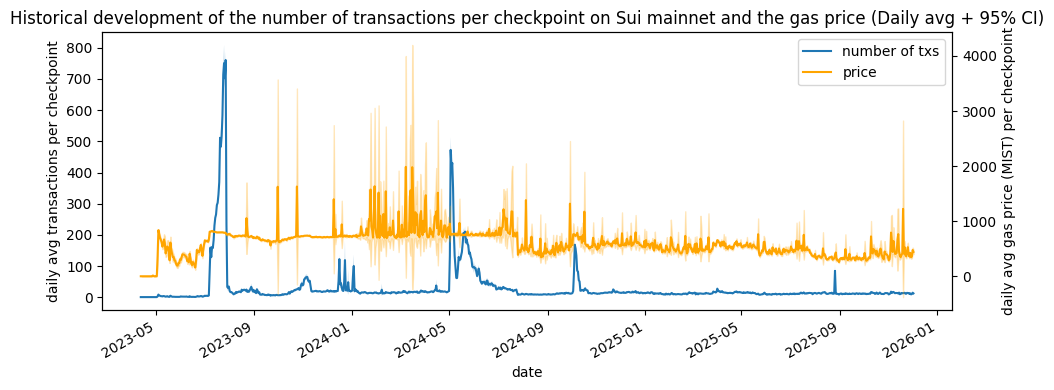

In [25]:
fig, ax1 = plt.subplots(figsize=(10, 4))

# tx count
ax1.plot(
    df_tx_price_daily["day"],
    df_tx_price_daily["tx_mean"],
    label="number of txs"
)
ax1.fill_between(
    df_tx_price_daily["day"],
    df_tx_price_daily["tx_mean"] - df_tx_price_daily["tx_ci95"],
    df_tx_price_daily["tx_mean"] + df_tx_price_daily["tx_ci95"],
    alpha=0.25
)
ax1.set_ylabel("daily avg transactions per checkpoint")
ax1.set_xlabel("date")

# gas price
ax2 = ax1.twinx()
ax2.plot(
    df_tx_price_daily["day"],
    df_tx_price_daily["price_mean"],
    label="price",
    color = "orange"
)
ax2.fill_between(
    df_tx_price_daily["day"],
    df_tx_price_daily["price_mean"] - df_tx_price_daily["price_ci95"],
    df_tx_price_daily["price_mean"] + df_tx_price_daily["price_ci95"],
    alpha=0.25,
    color="orange"
)
ax2.set_ylabel("daily avg gas price (MIST) per checkpoint")

ax1.set_title(
    "Historical development of the number of transactions per checkpoint on Sui mainnet "
    "and the gas price (Daily avg + 95% CI)"
)

ax1.xaxis.set_major_locator(mdates.AutoDateLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
fig.autofmt_xdate()

# combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)

plt.tight_layout()
plt.show()


Historical development of the number of concurrent write access per checkpoint

In [26]:
# graphs: dict[checkpoint] -> nx.Graph
# each graph has nodes = txs with ≥1 concurrent write edge

# 1) build per-checkpoint counts (ONLY txs with >=1 conflict edge)
df_cw = pd.DataFrame(
    [(int(cp), sum(1 for _, deg in G.degree() if deg > 0)) for cp, G in graphs.items()],
    columns=["checkpoint", "cw_tx_count"]
)

# 2) fetch timestamps for those checkpoints
checkpoints = df_cw["checkpoint"].tolist()

rows = []
chunk = 5000
for i in range(0, len(checkpoints), chunk):
    cps = checkpoints[i:i+chunk]
    placeholders = ",".join(["%s"] * len(cps))
    cur.execute(
        f"""
        SELECT sequence_number, timestamp
        FROM checkpoints
        WHERE sequence_number IN ({placeholders})
        """,
        cps
    )
    rows.extend(cur.fetchall())

df_ts = pd.DataFrame(rows, columns=["checkpoint", "timestamp"])
df_ts["checkpoint"] = df_ts["checkpoint"].astype(int)
df_ts["timestamp"] = pd.to_datetime(df_ts["timestamp"], utc=True)

# 3) merge
df_plot = (
    df_cw
    .merge(df_ts, on="checkpoint", how="inner")
)

# 4) daily aggregation + 95% CI
df_cw_daily = (
    df_plot
    .assign(day=df_plot["timestamp"].dt.date)
    .groupby("day")["cw_tx_count"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

df_cw_daily["cw_ci95"] = (
    1.96 * df_cw_daily["std"] / np.sqrt(df_cw_daily["count"])
)

df_cw_daily["day"] = pd.to_datetime(df_cw_daily["day"])
df_cw_daily = df_cw_daily.rename(columns={"mean": "cw_mean"})

# ensure numeric + clean
df_cw_daily[["cw_mean", "cw_ci95"]] = df_cw_daily[["cw_mean", "cw_ci95"]].astype(float)
df_cw_daily = df_cw_daily.dropna(subset=["cw_mean", "cw_ci95"])


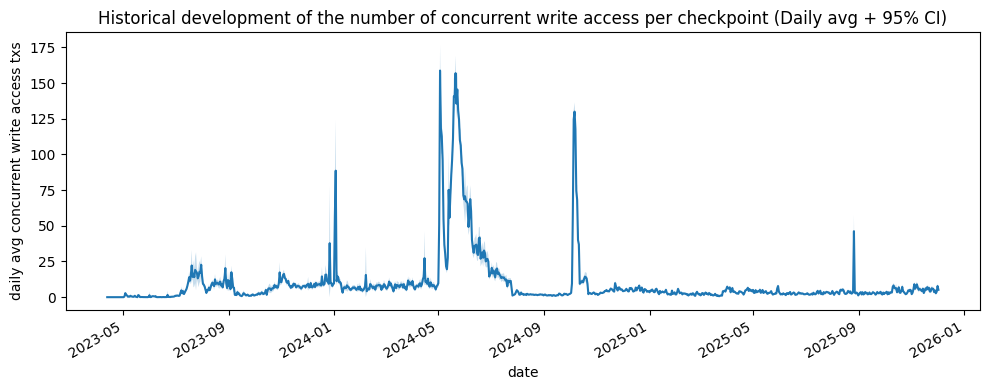

In [27]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(
    df_cw_daily["day"],
    df_cw_daily["cw_mean"]
)
ax.fill_between(
    df_cw_daily["day"],
    (df_cw_daily["cw_mean"] - df_cw_daily["cw_ci95"]).clip(lower=0),
    df_cw_daily["cw_mean"] + df_cw_daily["cw_ci95"],
    alpha=0.25
)

ax.set_ylabel("daily avg concurrent write access txs")
ax.set_xlabel("date")
ax.set_title(
    "Historical development of the number of concurrent write access per checkpoint "
    "(Daily avg + 95% CI)"
)

ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
fig.autofmt_xdate()

plt.tight_layout()
plt.show()


Daily average of gas used

In [28]:
cur.execute("""
    SELECT
        t.checkpoint_sequence AS checkpoint,
        t.gas_used,
        c.timestamp
    FROM transactions t
    JOIN checkpoints c
        ON t.checkpoint_sequence = c.sequence_number
""")

rows = cur.fetchall()

df_tx_gas = pd.DataFrame(
    rows,
    columns=["checkpoint", "gas_used", "timestamp"]
)

df_tx_gas["checkpoint"] = df_tx_gas["checkpoint"].astype(int)
df_tx_gas["gas_used"] = pd.to_numeric(df_tx_gas["gas_used"], errors="coerce")
df_tx_gas["timestamp"] = pd.to_datetime(df_tx_gas["timestamp"], utc=True)

# ---------- build df_block from df_tx ----------

df_block = (
    df_tx_gas
    .groupby("checkpoint")
    .agg(
        block_gas=("gas_used", "sum"),
        max_tx_gas=("gas_used", "max"),
        timestamp=("timestamp", "first"),
    )
    .reset_index()
)

In [29]:
# ---------- 1) prepare basics ----------

df_block["checkpoint"] = df_block["checkpoint"].astype(int)
df_block["timestamp"] = pd.to_datetime(df_block["timestamp"], utc=True)

df_lcc["checkpoint"] = df_lcc["checkpoint"].astype(int)
df_clique["checkpoint"] = df_clique["checkpoint"].astype(int)

df_tx_gas["checkpoint"] = df_tx_gas["checkpoint"].astype(int)
df_tx_gas["gas_used"] = pd.to_numeric(df_tx_gas["gas_used"], errors="coerce")

# tx count per checkpoint
df_tx_count = (
    df_tx_gas
    .groupby("checkpoint")
    .size()
    .rename("tx_count")
    .reset_index()
)

# ---------- 2) merge everything ----------

df = (
    df_block
    .merge(df_lcc, on="checkpoint", how="inner")
    .merge(df_clique, on="checkpoint", how="inner")
    .merge(df_tx_count, on="checkpoint", how="inner")
)

# ---------- 3) approximate CC / clique gas ----------

df["avg_tx_gas"] = df["block_gas"] / df["tx_count"]
df["cc_gas"] = df["largest_cc"] * df["avg_tx_gas"]
df["clique_gas"] = df["clique_size"] * df["avg_tx_gas"]

# ---------- 4) daily aggregation + 95% CI ----------

metrics = {
    "block_gas": "block_gas",
    "cc_gas": "cc_gas",
    "clique_gas": "clique_gas",
    "max_tx_gas": "max_tx_gas",
}

df_gas_daily = (
    df
    .assign(day=df["timestamp"].dt.date)
    .groupby("day")[list(metrics.values())]
    .agg(["mean", "std", "count"])
)

# flatten columns
df_gas_daily.columns = ["_".join(c) for c in df_gas_daily.columns]
df_gas_daily = df_gas_daily.reset_index()

# compute 95% CI
for m in metrics.values():
    df_gas_daily[f"{m}_ci95"] = (
        1.96 * df_gas_daily[f"{m}_std"] / np.sqrt(df_gas_daily[f"{m}_count"])
    )

df_gas_daily["day"] = pd.to_datetime(df_gas_daily["day"])

# numeric safety
cols = [c for c in df_gas_daily.columns if c != "day"]
df_gas_daily[cols] = df_gas_daily[cols].astype(float)

# optional cleanup
df_gas_daily = df_gas_daily.dropna(
    subset=[f"{m}_mean" for m in metrics.values()]
)


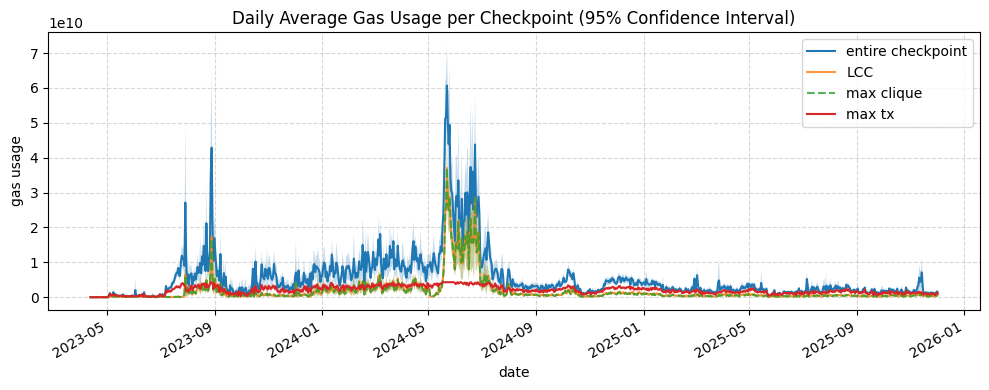

In [33]:
fig, ax = plt.subplots(figsize=(10, 4))

def plot_ci(x, mean, ci, label):
    ax.plot(x, mean, label=label)
    ax.fill_between(
        x,
        (mean - ci).clip(lower=0),
        mean + ci,
        alpha=0.25
    )

x = df_gas_daily["day"]

plot_ci(x, df_gas_daily["block_gas_mean"],  df_gas_daily["block_gas_ci95"],  "entire checkpoint")
plot_ci(x, df_gas_daily["cc_gas_mean"], df_gas_daily["cc_gas_ci95"], "LCC")
ax.lines[-1].set_alpha(0.8)

plot_ci(x, df_gas_daily["clique_gas_mean"], df_gas_daily["clique_gas_ci95"], "max clique")
ax.lines[-1].set_linestyle("--")
ax.lines[-1].set_alpha(0.8)
plot_ci(x, df_gas_daily["max_tx_gas_mean"], df_gas_daily["max_tx_gas_ci95"], "max tx")

ax.grid(True, which="both", ls="--", alpha=0.5)

ax.set_ylabel("gas usage")
ax.set_xlabel("date")
ax.set_title("Daily Average Gas Usage per Checkpoint (95% Confidence Interval)")

ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
fig.autofmt_xdate()

ax.legend()
plt.tight_layout()
plt.show()


Higest speed up factor

In [31]:
# ---------- build df_speedup_daily ----------

df_speedup_daily = pd.DataFrame()
df_speedup_daily["day"] = df_gas_daily["day"]

# lower bound: total / LCC
df_speedup_daily["speedup_lb"] = (
    df_gas_daily["block_gas_mean"] / df_gas_daily["cc_gas_mean"]
)

# upper bound: total / max clique
df_speedup_daily["speedup_ub"] = (
    df_gas_daily["block_gas_mean"] / df_gas_daily["clique_gas_mean"]
)

# ---------- 95% CI via delta method ----------

def ratio_ci(mean_a, ci_a, mean_b, ci_b):
    ratio = mean_a / mean_b
    rel_err = np.sqrt((ci_a / mean_a) ** 2 + (ci_b / mean_b) ** 2)
    return ratio * rel_err

df_speedup_daily["speedup_lb_ci95"] = ratio_ci(
    df_gas_daily["block_gas_mean"],
    df_gas_daily["block_gas_ci95"],
    df_gas_daily["cc_gas_mean"],
    df_gas_daily["cc_gas_ci95"],
)

df_speedup_daily["speedup_ub_ci95"] = ratio_ci(
    df_gas_daily["block_gas_mean"],
    df_gas_daily["block_gas_ci95"],
    df_gas_daily["clique_gas_mean"],
    df_gas_daily["clique_gas_ci95"],
)

# numeric safety
cols = ["speedup_lb", "speedup_lb_ci95", "speedup_ub", "speedup_ub_ci95"]
df_speedup_daily[cols] = df_speedup_daily[cols].astype(float)

# optional cleanup
df_speedup_daily = df_speedup_daily.replace([np.inf, -np.inf], np.nan)
df_speedup_daily = df_speedup_daily.dropna(subset=cols)


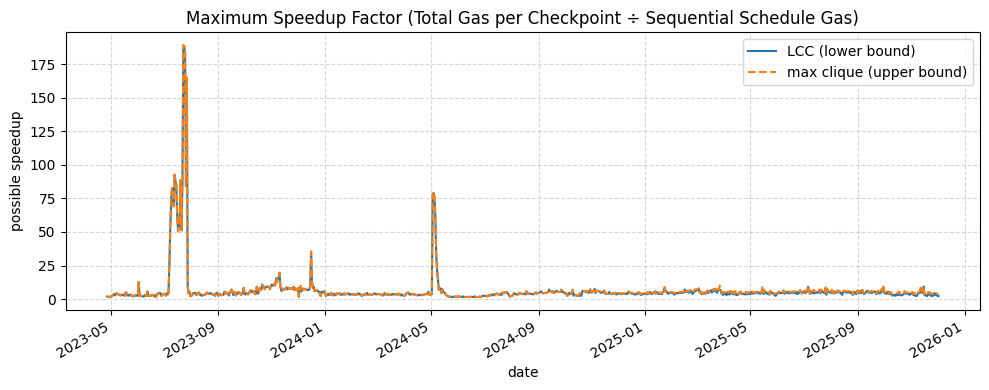

In [32]:
fig, ax = plt.subplots(figsize=(10, 4))

# lower bound (LCC)
ax.plot(
    df_speedup_daily["day"],
    df_speedup_daily["speedup_lb"],
    label="LCC (lower bound)"
)
"""ax.fill_between(
    df_speedup_daily["day"],
    (df_speedup_daily["speedup_lb"] - df_speedup_daily["speedup_lb_ci95"]).clip(lower=0),
    df_speedup_daily["speedup_lb"] + df_speedup_daily["speedup_lb_ci95"].clip(lower=0),
    alpha=0.25
)"""

# upper bound (max clique)
ax.plot(
    df_speedup_daily["day"],
    df_speedup_daily["speedup_ub"],
    label="max clique (upper bound)"
)
"""ax.fill_between(
    df_speedup_daily["day"],
    (df_speedup_daily["speedup_ub"] - df_speedup_daily["speedup_ub_ci95"]).clip(lower=0),
    df_speedup_daily["speedup_ub"] + df_speedup_daily["speedup_ub_ci95"].clip(lower=0),
    alpha=0.25
)"""
ax.lines[-1].set_linestyle("--")

ax.grid(True, which="both", ls="--", alpha=0.5)

ax.set_ylabel("possible speedup")
ax.set_xlabel("date")
ax.set_title(
    "Maximum Speedup Factor (Total Gas per Checkpoint ÷ Sequential Schedule Gas)"
)

ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
fig.autofmt_xdate()

ax.legend()
plt.tight_layout()
plt.show()
